In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# What drives the price of a car?

**BUSINESS UNDERSTANDING**

My goal is to understand which vehicle characteristics are associated with the price of used vehicles. I will use exploratory data analysis and regression techniques to analyze the provided dataset and identify relationships between the vehicle features and the target variable, vehicle price. The results will help the dealership make informed decisions regarding used vehicle inventory and pricing.

## Data Understanding

**DATASET ANALYSIS**

I will first examine the structure of the dataset, including the number of observations, variables, data types, and a few sample observations. I will then asses the completeness of the data by examining the number of missing values. I will use descriptive statistics to understand the numerical variables, and frequency counts to understand the categorical variables. I will also look for any outliers and impossible or strange values.
Lastly, I will explore any relationships between vehicle characteristics and price that may be useful for addressing the business problem.

### Dataset Structure and Summary


In [3]:
# Load the used-vehicle dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/vehicles.csv')

In [4]:
df.shape

(426880, 18)

In [5]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [7]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### Price Distribution


In [8]:
df['price'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

,price
0.900,37590.0
0.950,44500.0
0.990,66995.0
0.995,77000.0
0.999,120000.0


The price variable has no missing values, but some of these values are extremely large. The median price is about \$14K, and 99.9% of the vehicle prices are at or below \$120K. Some extreme values follow suspicious numerical patterns and will need to be investigated alongside the maximum value of $373M.  These values may present data quality issues and will need to be examined during Data Preparation.

### Model Year


In [9]:
df['year'].value_counts().sort_index().head(20)

,count
year,
1900.0,12
1901.0,3
1902.0,1
1903.0,12
1905.0,1
1909.0,1
1910.0,2
1913.0,2
1915.0,1


In [10]:
df[df['year'] == 1900][['price', 'manufacturer', 'model', 'condition', 'odometer', 'type']]

,price,manufacturer,model,condition,odometer,type
29955,1,NaN,All,fair,100000.0,other
32544,1,NaN,All,fair,100000.0,other
42454,38250,acura,rdx,new,4500.0,SUV
44754,1,NaN,All,good,1000.0,other
94319,1,ford,power wagon,NaN,2300.0,NaN
95914,1,ford,power wagon,NaN,2300.0,NaN
96564,1,ford,power wagon,NaN,2300.0,NaN
123023,4500,NaN,cushman white van,excellent,2136.0,NaN
126977,1,NaN,The earth is flat,good,123000.0,NaN
154138,75,NaN,any and all,NaN,10000.0,NaN


Very early model years are rare, and examination of the 1900 records reveals several implausible combinations of year, manufacturer, and model. This suggests that at least some of the oldest model-year observations contain
unreliable data.

### Odometer Mileage


In [11]:
df['odometer'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

,odometer
0.900,177377.100
0.950,204000.000
0.990,280000.000
0.995,350753.945
0.999,1111111.000


The odometer variable contains extreme values. While 99% of observations are at or below 280,000 miles, the maximum recorded mileage is 10,000,000, with multiple observations containing exactly this value. This suggests that some high-mileage values may represent placeholders or incorrect data and should be addressed during data preparation.

### Missing Values


In [12]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False)

,0
size,71.767476
cylinders,41.622470
condition,40.785232
VIN,37.725356
drive,30.586347
paint_color,30.501078
type,21.752717
manufacturer,4.133714
title_status,1.930753
model,1.236179


Size has approximately 72% missing values, while several other potentially useful vehicle characteristics have 20–42% missingness. This will need to be considered during Data Preparation.

### Vehicle Condition


In [13]:
df['condition'].value_counts(dropna=False)

,count
condition,
NaN,174104
good,121456
excellent,101467
like new,21178
fair,6769
new,1305
salvage,601


Condition contains six defined categories, with good and excellent being the most common. The categories appear consistently labeled, although some categories such as new and salvage are relatively uncommon. Approximately 41% of observations are missing a condition value, which may limit the usefulness of this feature and will need to be addressed during data preparation.

### Vehicle Condition and Price

Vehicle condition may provide useful information about how vehicles are priced. I will compare the median listing price across the reported vehicle condition categories. The median is used instead of the mean because vehicle prices contain high-value observations that could disproportionately influence the average.

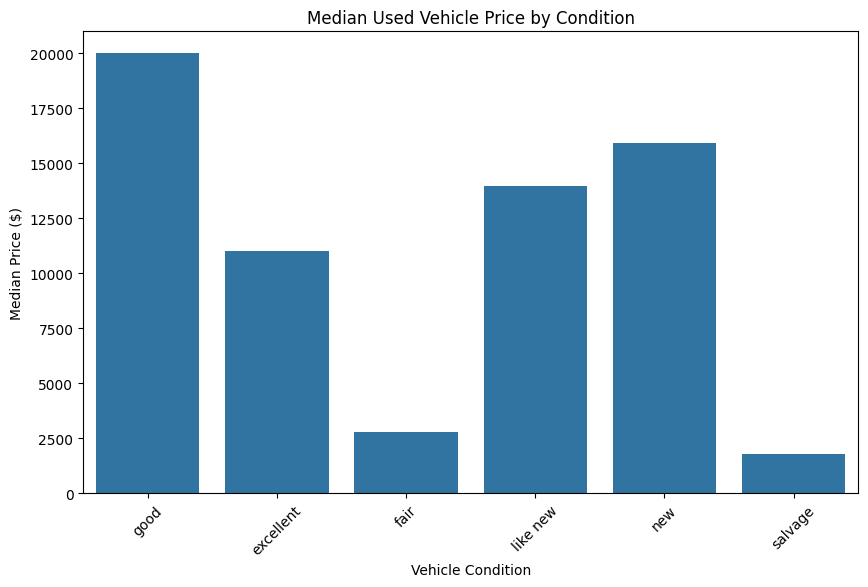

In [14]:
# Compare median vehicle prices across condition categories
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='condition',
    y='price',
    estimator=np.median,
    errorbar=None
)

plt.title('Median Used Vehicle Price by Condition')
plt.xlabel('Vehicle Condition')
plt.ylabel('Median Price ($)')
plt.xticks(rotation=45)
plt.show()

Vehicles in good condition have the highest median price. My initial assumption was that new, like new, or excellent vehicles would have a higher median price, so this result was unexpected. Fair and salvage vehicles understandably have lower median prices. This suggests that condition alone does not explain vehicle price and that other vehicle characteristics may also be influencing these differences.

### Categorical Feature Cardinality


In [15]:
categorical_columns = df.select_dtypes(include='object').columns

df[categorical_columns].nunique()

,0
region,404
manufacturer,42
model,29649
condition,6
cylinders,8
fuel,5
title_status,6
transmission,3
VIN,118246
drive,3


The categorical variables vary substantially in cardinality. Several features such as condition, fuel type, transmission, and drive contain relatively few categories, while model and VIN contain very large numbers of unique values. High-cardinality variables such as model may require additional preprocessing before modeling, while VIN appears to function primarily as an identifier.

In [16]:
for col in categorical_columns:
    if df[col].nunique() <= 15:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))


condition:
condition
NaN          174104
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

cylinders:
cylinders
NaN             177678
6 cylinders      94169
4 cylinders      77642
8 cylinders      72062
5 cylinders       1712
10 cylinders      1455
other             1298
3 cylinders        655
12 cylinders       209
Name: count, dtype: int64

fuel:
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
NaN           3013
electric      1698
Name: count, dtype: int64

title_status:
title_status
clean         405117
NaN             8242
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64

transmission:
transmission
automatic    336524
other         62682
manual        25118
NaN            2556
Name: count, dtype: int64

drive:
drive
4wd    131904
NaN    130567
fwd    105517
rwd     58892


The data contains missing values, extreme/suspicious prices and odometer readings, implausible year/model combinations, high-cardinality features, and sparsely represented categories.

## Data Preparation

### Initial Feature Removal


In [17]:
# Create a working copy and remove identifier columns that do not generalize to pricing
cars = df.copy()
cars = cars.drop(columns=['id', 'VIN'])
cars.shape

(426880, 16)

The id and VIN variables were removed because they primarily serve as identifiers rather than generalizable vehicle characteristics that are useful for explaining vehicle price.

### Price Cleaning


In [18]:
cars['price'].value_counts().loc[[0, 1]]

,count
price,
0,32895
1,1951


In [19]:
for threshold in [100, 500, 1000, 2000, 3000]:
    count = (cars['price'] < threshold).sum()
    percent = count / len(cars) * 100
    print(f"Below ${threshold}: {count} ({percent:.2f}%)")

Below $100: 36222 (8.49%)
Below $500: 42094 (9.86%)
Below $1000: 46315 (10.85%)
Below $2000: 52977 (12.41%)
Below $3000: 63816 (14.95%)


In [20]:
cars[(cars['price'] > 1) & (cars['price'] < 100)][
    ['price', 'year', 'manufacturer', 'model', 'condition', 'odometer', 'title_status']
].head(20)

,price,year,manufacturer,model,condition,odometer,title_status
96,80,2004.0,honda,NaN,excellent,94020.0,clean
1999,3,2020.0,ford,fusion se sedan,NaN,10.0,clean
2345,35,2006.0,chevrolet,trailblazer,NaN,161000.0,clean
4914,24,2020.0,NaN,all,NaN,100.0,clean
5727,10,2011.0,volkswagen,gti,good,119000.0,clean
9693,11,2014.0,nissan,nv2500,good,235000.0,clean
10031,11,2012.0,nissan,xterra s,excellent,143000.0,clean
10566,30,2015.0,cadillac,escalade esv,excellent,124000.0,clean
11881,11,1986.0,chevrolet,NaN,NaN,109000.0,clean
13921,7,1952.0,NaN,Dodge. Pilot house truck,good,9500.0,clean


Listings below \$100 were excluded because inspection showed that these records generally represented complete vehicles with implausibly low prices rather than meaningful vehicle prices. A conservative $100 lower bound was selected to remove likely placeholder or erroneous target values while retaining inexpensive vehicles.

In [21]:
for threshold in [100000, 150000, 200000, 500000, 1000000]:
    count = (cars['price'] > threshold).sum()
    percent = count / len(cars) * 100
    print(f"Above ${threshold:,}: {count} ({percent:.3f}%)")

Above $100,000: 655 (0.153%)
Above $150,000: 196 (0.046%)
Above $200,000: 124 (0.029%)
Above $500,000: 68 (0.016%)
Above $1,000,000: 53 (0.012%)


In [22]:
cars[cars['price'] > 500000][
    ['price', 'year', 'manufacturer', 'model', 'condition', 'odometer']
].sort_values('price').head(30)

,price,year,manufacturer,model,condition,odometer
106361,516999,2016.0,NaN,Lambo Aventador SV Roadster,like new,9982.0
208617,554900,2019.0,NaN,f250 xlt crewcab,excellent,25365.0
149860,566567,2006.0,chrysler,300,NaN,130000.0
79088,655000,2010.0,chrysler,town & country,good,106000.0
307671,777777,2012.0,gmc,sierra,NaN,144000.0
307513,777777,2012.0,gmc,sierra,NaN,144000.0
95119,990000,2017.0,mercedes-benz,amg g 63,NaN,4085.0
416145,999999,2006.0,ford,f-350,NaN,204123.0
232829,1000000,2016.0,ford,f150,NaN,100000.0
233201,1000000,2016.0,ford,f150,NaN,100000.0


Above \$500,000, inspection revealed numerous suspicious prices with repeated numerical patterns and implausible model information. Although some observations in this range may be legitimate, they represent a very small portion of the dataset. A $500,000 upper threshold was selected to reduce the influence of likely incorrect records while retaining the overwhelming majority of plausible vehicle listings.

In [23]:
# Retain listings within the selected plausible price range
cars = cars[
    (cars['price'] >= 100) &
    (cars['price'] <= 500000)
].copy()

cars.shape

(390590, 16)

In [24]:
cars['price'].describe()

,price
count,390590.000000
mean,19062.620902
std,15364.365696
min,100.000000
25%,7495.000000
50%,15500.000000
75%,27900.000000
max,470000.000000


Listings below \$100 were removed after inspection indicated that many represented placeholder or implausible vehicle prices. Listings above $500,000 were also removed after inspection revealed numerous patterned prices and implausible listing information. Although some legitimate high-value vehicles may have been excluded, these observations represented a very small proportion of the dataset. After filtering, 390,590 observations remained.

### Model Year Cleaning


In [25]:
for year in [1920, 1930, 1940, 1950, 1960, 1970]:
    count = (cars['year'] < year).sum()
    print(f"Before {year}: {count}")

Before 1920: 17
Before 1930: 214
Before 1940: 676
Before 1950: 1136
Before 1960: 2311
Before 1970: 5018


In [26]:
cars[cars['year'] < 1930][
    ['year', 'price', 'manufacturer', 'model', 'condition', 'odometer']
].sort_values('year').head(30)

,year,price,manufacturer,model,condition,odometer
42454,1900.0,38250,acura,rdx,new,4500.0
123023,1900.0,4500,NaN,cushman white van,excellent,2136.0
269472,1900.0,998,NaN,any,NaN,123456.0
398032,1900.0,500,dodge,rampage,salvage,999999.0
183832,1901.0,100,NaN,rolls royce phantom,NaN,1000.0
277762,1901.0,4000,NaN,olds type r,good,100.0
10353,1901.0,999,NaN,ALL,NaN,1.0
289145,1905.0,3990,chevrolet,astro cargo,excellent,202570.0
383491,1909.0,750,NaN,Mitsubshi FBC15K,salvage,999999.0
322057,1910.0,15000,NaN,1910 MAXWELL AA,excellent,1.0


Records before 1930 contained a mixture of implausible listings and legitimate antique vehicles. Because these observations represented a very small portion of the dataset and antique vehicles may follow substantially different pricing dynamics from the general used-car market, vehicles before 1930 were excluded from the modeling dataset

In [27]:
# Retain model years within the selected analysis range
cars = cars[
    (cars['year'] >= 1930) &
    (cars['year'] <= 2022)
].copy()

cars.shape

(389203, 16)

In [28]:
cars['year'].describe()

,year
count,389203.000000
mean,2011.066372
std,9.356749
min,1930.000000
25%,2008.000000
50%,2013.000000
75%,2017.000000
max,2022.000000


### Odometer Cleaning


In [29]:
cars['odometer'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

,odometer
0.900,179225.000
0.950,205758.000
0.990,280000.000
0.995,345130.645
0.999,1111111.000


In [30]:
cars['odometer'].isna().sum()
cars['odometer'].isna().mean() * 100

np.float64(0.5701394901889246)

In [31]:
for threshold in [100000, 150000, 200000, 500000, 1000000]:
    count = (cars['odometer'] > threshold).sum()
    percent = count / len(cars) * 100
    print(f"Above {threshold}: {count} ({percent:.3f}%)")

Above 100000: 165014 (42.398%)
Above 150000: 72780 (18.700%)
Above 200000: 22114 (5.682%)
Above 500000: 1167 (0.300%)
Above 1000000: 436 (0.112%)


In [32]:
cars[cars['odometer'] > 1000000][
    ['odometer', 'year', 'price', 'manufacturer', 'model', 'condition']
].sort_values('odometer', ascending=False).head(30)

,odometer,year,price,manufacturer,model,condition
391620,10000000.0,1968.0,29900,chevrolet,corvette,NaN
390252,10000000.0,1964.0,2000,ford,f-150,fair
67003,10000000.0,2007.0,7800,toyota,NaN,NaN
386654,10000000.0,1957.0,15000,chevrolet,nomad,NaN
386655,10000000.0,1967.0,7000,NaN,1967,fair
340694,10000000.0,2006.0,10000,lexus,rx 330,NaN
67001,10000000.0,1974.0,4350,chevrolet,NaN,NaN
346469,10000000.0,1973.0,1700,NaN,1973 nova,NaN
28738,10000000.0,1951.0,20000,chevrolet,coe,good
44280,10000000.0,1975.0,16000,porsche,914,good


In [33]:
cars[cars['odometer'] > 1000000]['odometer'].value_counts().head(20)

,count
odometer,
9999999.0,62
10000000.0,40
1111111.0,33
1234567.0,26
7777777.0,13
4728224.0,8
1200000.0,7
2000000.0,6
1640001.0,6


Odometer readings above 1 million miles were removed because inspection of the extreme upper tail revealed numerous repeated and patterned values indicative of unreliable or placeholder data. This affected approximately 0.1% of the dataset. High-mileage observations below this threshold were retained because they could represent legitimate high-use vehicles.

In [34]:
# Remove missing odometer values and extreme readings above 1,000,000 miles
cars = cars[
    (cars['odometer'] >= 0) &
    (cars['odometer'] <= 1000000)
].copy()

cars.shape

(386548, 16)

In [35]:
cars['odometer'].describe()

,odometer
count,386548.000000
mean,94104.224241
std,71906.912274
min,0.000000
25%,38282.000000
50%,87365.000000
75%,135607.000000
max,1000000.000000


### Remaining Missing Values


In [36]:
missing_pct = cars.isna().mean() * 100
missing_pct.sort_values(ascending=False)

,0
size,71.969070
cylinders,40.645664
condition,38.143258
drive,30.514451
paint_color,29.577181
type,21.580502
manufacturer,3.742097
title_status,1.867297
model,1.153026
fuel,0.549738


### Removing the Size Feature


In [37]:
cars['size'].value_counts(dropna=False)

,count
size,
NaN,278195
full-size,56898
mid-size,31559
compact,17080
sub-compact,2816


In [38]:
# Drop size because roughly 72% of its values are missing
cars = cars.drop(columns=['size'])

Size was excluded as a predictor because approximately 72% of its observations were missing, making reliable imputation and row-wise deletion difficult.

### Handling Missing Categorical Values

Several categorical variables contained missing values. Rather than dropping these observations or attempting to infer categories that were not reported, I will replace missing categorical values with "unknown". This preserves the observations while allowing missing information to be represented as its own category during modeling.

In [39]:
# Replace missing categorical values with an explicit "unknown" category
unknown_cols = [
    'cylinders', 'condition', 'drive', 'paint_color', 'type',
    'manufacturer', 'title_status', 'model', 'fuel', 'transmission'
]

cars[unknown_cols] = cars[unknown_cols].fillna('unknown')

# Verify that missing categorical values were handled
cars[unknown_cols].isna().sum()

,0
cylinders,0
condition,0
drive,0
paint_color,0
type,0
manufacturer,0
title_status,0
model,0
fuel,0
transmission,0


### High-Cardinality Vehicle Model


In [40]:
# Measure model cardinality before deciding how to encode it
cars['model'].nunique()

27613

In [41]:
(cars['model'].value_counts() == 1).sum()

np.int64(14294)

In [42]:
cars['model_clean'] = (
    cars['model']
    .str.lower()
    .str.strip()
)

cars['model_clean'] = (
    cars['model_clean']
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [43]:
cars['model_clean'].nunique()

26169

In [44]:
# Compare infrequent-category thresholds for the high-cardinality model feature
for threshold in [5, 10, 20, 50, 100]:
    model_counts = cars['model'].value_counts()

    rare_models = model_counts[model_counts < threshold].index
    rare_records = cars['model'].isin(rare_models).sum()

    remaining_categories = (model_counts >= threshold).sum()

    print(
        f"Minimum {threshold}: "
        f"{remaining_categories} retained categories, "
        f"{rare_records} records grouped as other "
        f"({rare_records / len(cars) * 100:.2f}%)"
    )

Minimum 5: 6707 retained categories, 31748 records grouped as other (8.21%)
Minimum 10: 4110 retained categories, 48660 records grouped as other (12.59%)
Minimum 20: 2454 retained categories, 71305 records grouped as other (18.45%)
Minimum 50: 1147 retained categories, 111329 records grouped as other (28.80%)
Minimum 100: 612 retained categories, 148927 records grouped as other (38.53%)


In [45]:
cars.isna().sum().sort_values(ascending=False)

,0
region,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0


In [46]:
cars.shape

(386548, 16)

### Feature Engineering


In [47]:
# Convert model year to age using 2022, the latest year represented in the dataset
cars['vehicle_age'] = 2022 - cars['year']
cars['vehicle_age'].describe()

,vehicle_age
count,386548.000000
mean,10.920579
std,9.330944
min,0.000000
25%,5.000000
50%,9.000000
75%,14.000000
max,92.000000


### Cleaned Data Visualizations


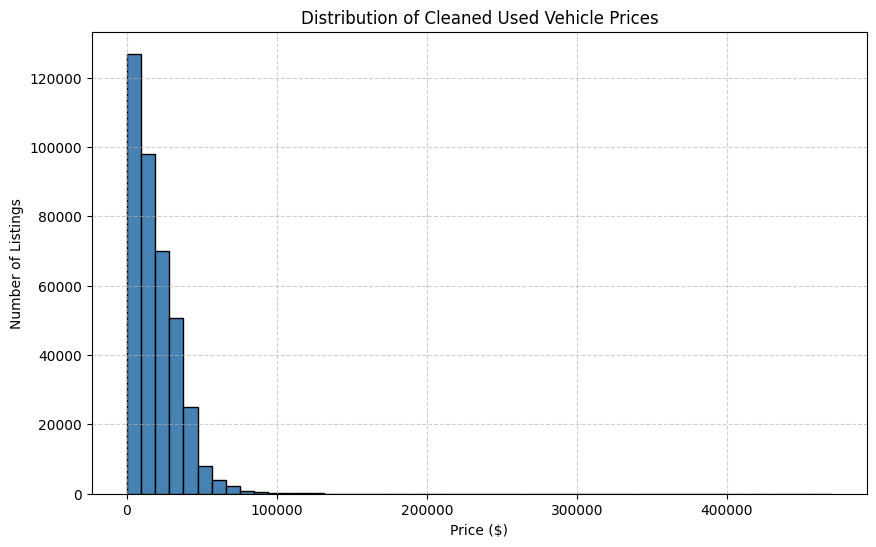

In [48]:
plt.figure(figsize=(10, 6))
plt.hist(cars['price'], bins=50, edgecolor='black', color='steelblue')
plt.title('Distribution of Cleaned Used Vehicle Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

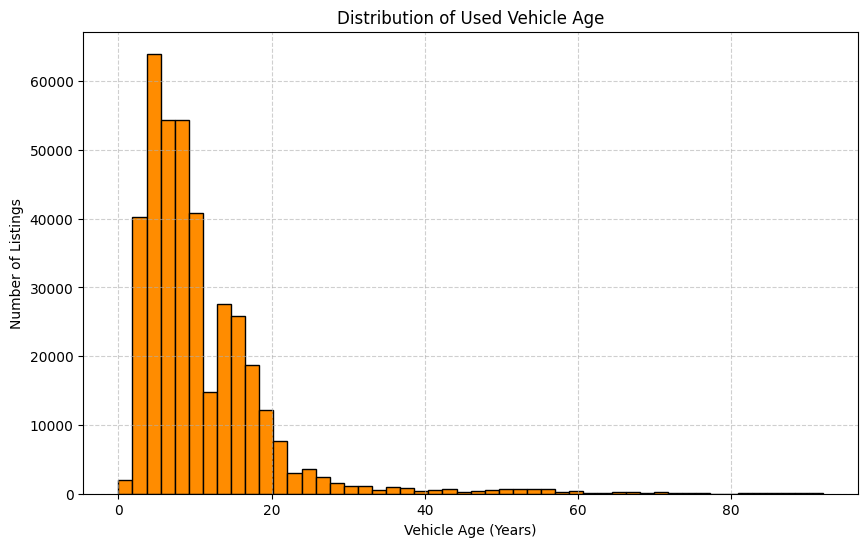

In [49]:
plt.figure(figsize=(10, 6))
plt.hist(cars['vehicle_age'], bins=50, edgecolor='black', color='darkorange')
plt.title('Distribution of Used Vehicle Age')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Number of Listings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

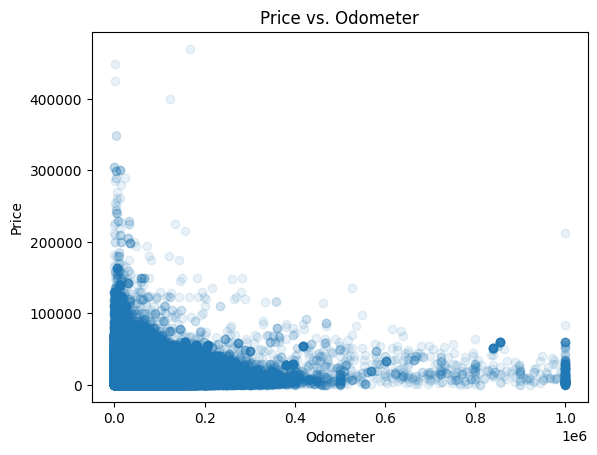

In [50]:
plt.scatter(cars['odometer'], cars['price'], alpha=0.1)
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.title('Price vs. Odometer')
plt.show()

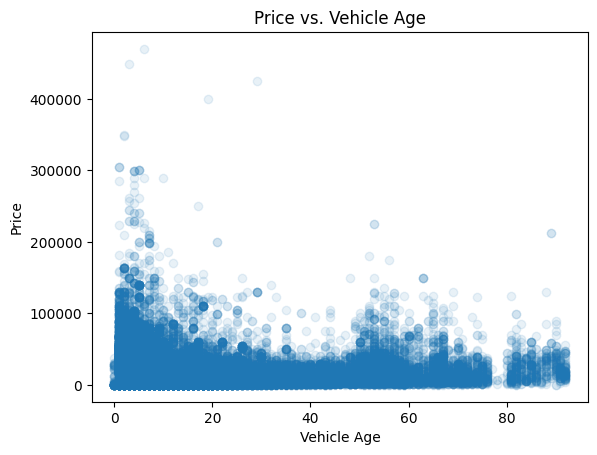

In [51]:
plt.scatter(cars['vehicle_age'], cars['price'], alpha=0.1)
plt.xlabel('Vehicle Age')
plt.ylabel('Price')
plt.title('Price vs. Vehicle Age')
plt.show()

### Mileage and Price Relationship


In [52]:
# Bin mileage to examine how median price changes across mileage ranges
cars['odometer_bin'] = pd.cut(
    cars['odometer'],
    bins=[0, 25000, 50000, 75000, 100000, 150000,
          200000, 300000, 500000, 1000000],
    include_lowest=True
)

cars.groupby('odometer_bin', observed=True)['price'].median()

,price
odometer_bin,
"(-0.001, 25000.0]",29990.0
"(25000.0, 50000.0]",25990.0
"(50000.0, 75000.0]",18995.0
"(75000.0, 100000.0]",13995.0
"(100000.0, 150000.0]",9700.0
"(150000.0, 200000.0]",6700.0
"(200000.0, 300000.0]",5500.0
"(300000.0, 500000.0]",7900.0
"(500000.0, 1000000.0]",16500.0


In [53]:
cars.groupby('odometer_bin', observed=True)['price'].count()

,price
odometer_bin,
"(-0.001, 25000.0]",63538
"(25000.0, 50000.0]",58405
"(50000.0, 75000.0]",46650
"(75000.0, 100000.0]",53377
"(100000.0, 150000.0]",92234
"(150000.0, 200000.0]",50666
"(200000.0, 300000.0]",19378
"(300000.0, 500000.0]",1569
"(500000.0, 1000000.0]",731


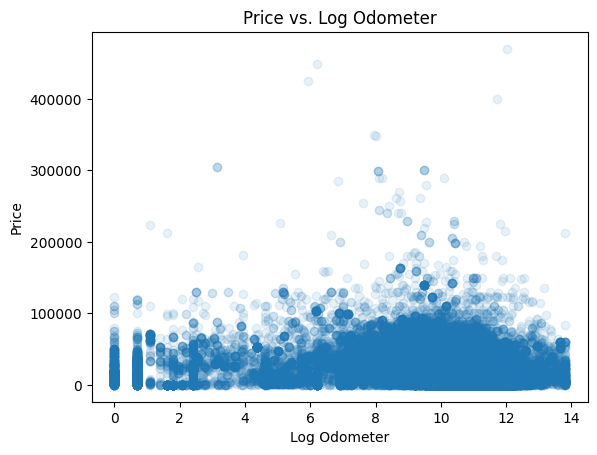

In [54]:
# Log-transform mileage to reduce right skew before comparing model performance
cars['log_odometer'] = np.log1p(cars['odometer'])

plt.scatter(cars['log_odometer'], cars['price'], alpha=0.1)
plt.xlabel('Log Odometer')
plt.ylabel('Price')
plt.title('Price vs. Log Odometer')
plt.show()

Cleaned integrity issues, handled missing data, evaluated high-cardinality features, engineered vehicle_age, and identified potential transformations for later modeling.

## Modeling

### Baseline Multiple Linear Regression

I will begin with a multiple linear regression model to establish a baseline for model performance. This model uses vehicle age, odometer mileage, and categorical vehicle characteristics to predict vehicle price.

In [55]:
# Define predictors and target for the baseline multiple linear regression
X = cars[[
    'vehicle_age',
    'odometer',
    'region',
    'manufacturer',
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]]

y = cars['price']

print(X.shape)
print(y.shape)

(386548, 13)
(386548,)


In [56]:
# Hold out 20% of the data for final baseline evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(309238, 13)
(77310, 13)
(309238,)
(77310,)


In [57]:
# Build preprocessing and the baseline linear-regression pipeline
numeric_features = [
    'vehicle_age',
    'odometer'
]

categorical_features = [
    'region',
    'manufacturer',
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'manufacturer',
                                                   'condition', 'cylinders',
                                                   'fuel', 'title_status',
                                                   'transmission', 'drive',
                                                   'type', 'paint_color',
                                                   'state'])])),
                ('regressor', LinearRegression())])

In [58]:
# Fit the baseline model and generate held-out predictions
linear_pipeline.fit(X_train, y_train)
y_pred = linear_pipeline.predict(X_test)

**MODEL EVALUATION METRICS**

I will use MAE, RMSE, and R² to evaluate model performance. MAE (Mean Absolute Error) measures the average difference between the predicted and actual vehicle prices. RMSE (Root Mean Squared Error) also measures prediction error but penalizes larger errors more heavily, which can help identify models that make substantial pricing errors. R² measures the proportion of variation in vehicle prices explained by the model.

I will primarily use MAE to compare models because the result can be directly interpreted as the average dollar error in predicted vehicle price. RMSE and R² will provide additional information about model performance.

In [59]:
# Evaluate baseline predictions using MAE, RMSE, and R²
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.3f}")

MAE: $7,441.45
RMSE: $11,826.66
R²: 0.422


In [60]:
# Use 5-fold cross-validation to estimate baseline model generalization performance
cv_results = cross_validate(
    linear_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

cv_mae = -cv_results['test_neg_mean_absolute_error']
cv_rmse = -cv_results['test_neg_root_mean_squared_error']
cv_r2 = cv_results['test_r2']

print("MAE:", cv_mae)
print("RMSE:", cv_rmse)
print("R²:", cv_r2)

print(f"Average CV MAE: ${cv_mae.mean():,.2f}")
print(f"Average CV RMSE: ${cv_rmse.mean():,.2f}")
print(f"Average CV R²: {cv_r2.mean():.3f}")

print(f"MAE Std Dev: ${cv_mae.std():,.2f}")
print(f"RMSE Std Dev: ${cv_rmse.std():,.2f}")
print(f"R² Std Dev: {cv_r2.std():.3f}")

MAE: [7343.74389237 7289.08861355 7298.64199023 7351.01802704 7323.04069397]
RMSE: [11505.66719631 11161.06613735 11164.29690103 11535.83024806
 11454.52874577]
R²: [0.43831707 0.44563679 0.45745895 0.43922421 0.43631108]
Average CV MAE: $7,321.11
Average CV RMSE: $11,364.28
Average CV R²: 0.443
MAE Std Dev: $24.25
RMSE Std Dev: $166.65
R² Std Dev: 0.008


### Linear Regression with Log-Transformed Odometer

Earlier exploratory analysis showed that odometer mileage was highly skewed and its relationship with price did not appear entirely linear. I will compare the baseline model with a second linear regression model using the log-transformed odometer variable.

In [61]:
# Build Model 2 using log-transformed mileage instead of raw odometer mileage
X_log = cars[[
    'vehicle_age',
    'log_odometer',
    'region',
    'manufacturer',
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]]

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log,
    y,
    test_size=0.20,
    random_state=42
)

In [62]:
# Use 5-fold cross-validation to evaluate the log-odometer model
log_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

log_pipeline = Pipeline([
    ('preprocessor', log_preprocessor),
    ('regressor', LinearRegression())
])

log_cv_results = cross_validate(
    log_pipeline,
    X_log_train,
    y_log_train,
    cv=5,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

log_cv_mae = -log_cv_results['test_neg_mean_absolute_error']
log_cv_rmse = -log_cv_results['test_neg_root_mean_squared_error']
log_cv_r2 = log_cv_results['test_r2']

print(f"Average CV MAE: ${log_cv_mae.mean():,.2f}")
print(f"Average CV RMSE: ${log_cv_rmse.mean():,.2f}")
print(f"Average CV R²: {log_cv_r2.mean():.3f}")

print(f"MAE Std Dev: ${log_cv_mae.std():,.2f}")
print(f"RMSE Std Dev: ${log_cv_rmse.std():,.2f}")
print(f"R² Std Dev: {log_cv_r2.std():.3f}")

Average CV MAE: $7,102.80
Average CV RMSE: $10,960.64
Average CV R²: 0.482
MAE Std Dev: $17.29
RMSE Std Dev: $116.31
R² Std Dev: 0.003


Replacing raw odometer mileage with a log-transformed odometer feature improved cross-validated model performance. Average MAE and RMSE decreased while R² increased, suggesting that the transformed mileage feature better represents its relationship with vehicle price.

### Ridge Regression

Next, I will evaluate Ridge regression to determine whether regularization improves model performance. Because Ridge penalizes the size of model coefficients, the numerical predictors will be standardized before fitting the model.

In [63]:
# Standardize numeric predictors and one-hot encode categorical predictors for Ridge
numeric_features_log = [
    'vehicle_age',
    'log_odometer'
]

ridge_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features_log
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

ridge_pipeline = Pipeline([
    ('preprocessor', ridge_preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100]
}

In [64]:
# Tune Ridge alpha using 5-fold cross-validation and MAE
ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

ridge_grid.fit(X_log_train, y_log_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['vehicle_age',
                                                                          'log_odometer']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['region',
                                                                          'manufacturer',
                                                                          'condition',
                                                                          'cylinders',
                                                                          'fuel',
                                                                          'title_status',
                                                                          'transmission',
                                                                          'drive',
                                                                          'type',
                                                                          'paint_color',
                                                                          'state'])])),
                                       ('regressor', Ridge())]),
             n_jobs=-1, param_grid={'regressor__alpha': [0.1, 1, 10, 100]},
             scoring='neg_mean_absolute_error')

In [65]:
ridge_grid.best_params_

{'regressor__alpha': 100}

In [66]:
-ridge_grid.best_score_

np.float64(7099.982964756078)

In [67]:
# Tune Ridge alpha using 5-fold cross-validation and MAE
param_grid = {
    'regressor__alpha': [10, 100, 1000, 10000]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

ridge_grid.fit(X_log_train, y_log_train)

print("Best alpha:", ridge_grid.best_params_)
print(f"Best CV MAE: ${-ridge_grid.best_score_:,.2f}")

Best alpha: {'regressor__alpha': 100}
Best CV MAE: $7,099.98


In [68]:
ridge_results = pd.DataFrame(ridge_grid.cv_results_)

ridge_results['mean_cv_mae'] = -ridge_results['mean_test_score']

ridge_results[[
    'param_regressor__alpha',
    'mean_cv_mae',
    'std_test_score'
]]

,param_regressor__alpha,mean_cv_mae,std_test_score
0,10,7100.393333,17.457389
1,100,7099.982965,19.714318
2,1000,7136.989428,26.902217
3,10000,7363.483606,30.326326


### Lasso Regression

Lasso regression was evaluated to determine whether regularization and feature selection could improve predictive performance. A 5-fold grid search tested alpha values of 0.1, 1, 10, and 100 using MAE as the scoring metric. The best-performing parameter was alpha = 1, which produced an average cross-validated MAE of approximately $7,096.

Lasso performed slightly better than the previous Ridge and linear regression models, although the improvement was small. Because Lasso required substantially more computation time while providing only a modest reduction in MAE, additional Lasso tuning was not pursued.

In [69]:
# Lasso experiment retained as commented code because the completed grid search was computationally expensive
# lasso_pipeline = Pipeline([
#     ('preprocessor', ridge_preprocessor),
#     ('regressor', Lasso(max_iter=10000))
# ])

# lasso_param_grid = {
#     'regressor__alpha': [0.1, 1, 10, 100]
# }

# lasso_grid = GridSearchCV(
#     estimator=lasso_pipeline,
#     param_grid=lasso_param_grid,
#     cv=5,
#     scoring='neg_mean_absolute_error',
#     n_jobs=-1
# )

# lasso_grid.fit(X_log_train, y_log_train)

# print("Best alpha:", lasso_grid.best_params_)
# print(f"Best CV MAE: ${-lasso_grid.best_score_:,.2f}")

# Best alpha: {'regressor__alpha': 1}
# Best CV MAE: $7,095.85

### Final Ridge Model with Vehicle Model

The previous models did not include the specific vehicle model because this variable contained a large number of unique categories. However, vehicle model may contain important pricing information beyond manufacturer alone. For the final model, I will include this feature while grouping infrequent categories during one-hot encoding.

In [70]:
# Use 5-fold cross-validation to evaluate the final Ridge model
# 1. Create predictor matrix that includes the model column

X_model = cars[[
    'vehicle_age',
    'log_odometer',
    'region',
    'manufacturer',
    'model',
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]]


# 2. Define numeric and categorical features

numeric_features_model = [
    'vehicle_age',
    'log_odometer'
]

categorical_features_model = [
    'region',
    'manufacturer',
    'model',
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]


# 3. Create the train/test split
# Same random_state preserves the same basic split used previously.

X_model_train, X_model_test, y_model_train, y_model_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42
)


# 4. Build preprocessing
# min_frequency=20 groups categories occurring fewer than 20 times in the training data into an infrequent category.

model_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features_model
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='infrequent_if_exist',
                min_frequency=20
            ),
            categorical_features_model
        )
    ]
)


# 5. Build Ridge pipeline using the alpha selected previously

model_ridge_pipeline = Pipeline([
    ('preprocessor', model_preprocessor),
    ('regressor', Ridge(alpha=100))
])


# 6. Perform 5-fold cross-validation on TRAINING DATA ONLY

model_cv_results = cross_validate(
    model_ridge_pipeline,
    X_model_train,
    y_model_train,
    cv=5,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ],
    n_jobs=-1
)


# 7. Convert scores into readable form

model_cv_mae = -model_cv_results['test_neg_mean_absolute_error']
model_cv_rmse = -model_cv_results['test_neg_root_mean_squared_error']
model_cv_r2 = model_cv_results['test_r2']


# 8. Print average CV performance

print("Model 4: Ridge Regression with Vehicle Model")
print("--------------------------------------------")
print(f"Average CV MAE: ${model_cv_mae.mean():,.2f}")
print(f"Average CV RMSE: ${model_cv_rmse.mean():,.2f}")
print(f"Average CV R²: {model_cv_r2.mean():.3f}")

print()
print(f"MAE Std Dev: ${model_cv_mae.std():,.2f}")
print(f"RMSE Std Dev: ${model_cv_rmse.std():,.2f}")
print(f"R² Std Dev: {model_cv_r2.std():.3f}")

Model 4: Ridge Regression with Vehicle Model
--------------------------------------------
Average CV MAE: $6,500.94
Average CV RMSE: $10,448.84
Average CV R²: 0.529

MAE Std Dev: $27.31
RMSE Std Dev: $154.90
R² Std Dev: 0.005


In [71]:
# Fit the final Ridge model and generate predictions on the untouched test set
model_ridge_pipeline.fit(X_model_train, y_model_train)
y_model_pred = model_ridge_pipeline.predict(X_model_test)

In [72]:
# Evaluate final held-out performance with the same metrics used throughout modeling
final_mae = mean_absolute_error(y_model_test, y_model_pred)
final_rmse = mean_squared_error(y_model_test, y_model_pred) ** 0.5
final_r2 = r2_score(y_model_test, y_model_pred)

print("Final Model Test Performance")
print("----------------------------")
print(f"MAE: ${final_mae:,.2f}")
print(f"RMSE: ${final_rmse:,.2f}")
print(f"R²: {final_r2:.3f}")

Final Model Test Performance
----------------------------
MAE: $6,524.99
RMSE: $10,771.16
R²: 0.521


In [73]:
final_results = pd.DataFrame({
    'Actual Price': y_model_test,
    'Predicted Price': y_model_pred
})

final_results.head(10)

final_results['Absolute Error'] = (
    final_results['Actual Price'] -
    final_results['Predicted Price']
).abs()

final_results.head(10)

,Actual Price,Predicted Price,Absolute Error
144959,50995,23182.949833,27812.050167
126092,50427,22393.415994,28033.584006
131066,2800,5043.049668,2243.049668
217760,15590,15875.414642,285.414642
260249,33500,12889.419100,20610.580900
108241,3395,5154.865388,1759.865388
20881,25990,31268.520503,5278.520503
400554,13999,14926.203918,927.203918
378090,47999,27946.631996,20052.368004
263135,1200,3043.979194,1843.979194


## Evaluation

### Coefficient Analysis


In [74]:
# Retrieve transformed feature names for coefficient interpretation
feature_names = (
    model_ridge_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

len(feature_names)

2632

In [75]:
coefficients = (
    model_ridge_pipeline
    .named_steps['regressor']
    .coef_
)

len(coefficients)

2632

In [76]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df.head()

,feature,coefficient
0,num__vehicle_age,-4452.708983
1,num__log_odometer,-3521.000196
2,cat__region_SF bay area,84.217031
3,cat__region_abilene,1381.177481
4,cat__region_akron / canton,-1228.605602


In [77]:
coef_df.sort_values(
    'coefficient',
    ascending=False
).head(20)

,feature,coefficient
413,cat__manufacturer_ferrari,37480.195204
664,cat__model_Mclaren 570GT W/ Upgrades,18738.763067
2525,cat__cylinders_12 cylinders,17230.189064
1014,cat__model_coupe,16719.036512
629,cat__model_911,16613.506506
1903,cat__model_q8 premium sport utility 4d,16599.655433
433,cat__manufacturer_porsche,12913.973894
438,cat__manufacturer_tesla,12903.728886
1003,cat__model_corvette,12384.238310
1328,cat__model_f250 lariat 4x4 diesel,10526.318685


In [78]:
coef_df.sort_values(
    'coefficient',
    ascending=True
).head(20)

,feature,coefficient
660,cat__model_Janesville,-8729.150816
430,cat__manufacturer_mitsubishi,-8176.555413
2176,cat__model_smart fortwo Passion Hatchback,-7787.126868
820,cat__model_boxster,-7396.586225
446,cat__model_1 series 128i coupe 2d,-7303.844736
1380,cat__model_focus,-7207.088453
414,cat__manufacturer_fiat,-7177.794815
1362,cat__model_fiesta,-7114.381219
2555,cat__type_bus,-7036.830767
631,cat__model_ALL,-6862.021522


In [79]:
# Group encoded coefficients by their original vehicle characteristic
def get_feature_group(feature):
    if feature.startswith('num__vehicle_age'):
        return 'vehicle_age'
    elif feature.startswith('num__log_odometer'):
        return 'odometer'
    elif feature.startswith('cat__manufacturer_'):
        return 'manufacturer'
    elif feature.startswith('cat__model_'):
        return 'model'
    elif feature.startswith('cat__condition_'):
        return 'condition'
    elif feature.startswith('cat__cylinders_'):
        return 'cylinders'
    elif feature.startswith('cat__fuel_'):
        return 'fuel'
    elif feature.startswith('cat__title_status_'):
        return 'title_status'
    elif feature.startswith('cat__transmission_'):
        return 'transmission'
    elif feature.startswith('cat__drive_'):
        return 'drive'
    elif feature.startswith('cat__type_'):
        return 'type'
    elif feature.startswith('cat__paint_color_'):
        return 'paint_color'
    elif feature.startswith('cat__region_'):
        return 'region'
    elif feature.startswith('cat__state_'):
        return 'state'
    else:
        return 'other'

coef_df['feature_group'] = coef_df['feature'].apply(get_feature_group)

In [80]:
coef_df[
    coef_df['feature_group'] == 'manufacturer'
].sort_values(
    'coefficient',
    ascending=False
)

,feature,coefficient,feature_group
413,cat__manufacturer_ferrari,37480.195204,manufacturer
433,cat__manufacturer_porsche,12913.973894,manufacturer
438,cat__manufacturer_tesla,12903.728886,manufacturer
435,cat__manufacturer_rover,5512.294595,manufacturer
411,cat__manufacturer_datsun,3726.933177,manufacturer
405,cat__manufacturer_audi,3297.189212,manufacturer
404,cat__manufacturer_alfa-romeo,2927.710028,manufacturer
443,cat__manufacturer_infrequent_sklearn,2601.913278,manufacturer
421,cat__manufacturer_jaguar,1808.074151,manufacturer
427,cat__manufacturer_mercedes-benz,1465.500542,manufacturer


In [81]:
coef_df[
    coef_df['feature_group'] == 'condition'
].sort_values(
    'coefficient',
    ascending=False
)

,feature,coefficient,feature_group
2521,cat__condition_new,3224.049547,condition
2523,cat__condition_unknown,2675.281548,condition
2520,cat__condition_like new,2669.265083,condition
2517,cat__condition_excellent,784.140083,condition
2519,cat__condition_good,-642.754745,condition
2522,cat__condition_salvage,-3284.991688,condition
2518,cat__condition_fair,-5424.989829,condition


In [82]:
coef_df[
    coef_df['feature_group'] == 'title_status'
].sort_values(
    'coefficient',
    ascending=False
)

,feature,coefficient,feature_group
2540,cat__title_status_lien,4088.987581,title_status
2539,cat__title_status_clean,2580.045516,title_status
2541,cat__title_status_missing,1619.949393,title_status
2543,cat__title_status_rebuilt,-420.658807,title_status
2545,cat__title_status_unknown,-1971.014564,title_status
2544,cat__title_status_salvage,-2051.097248,title_status
2542,cat__title_status_parts only,-3846.211869,title_status


Age and mileage are negatively associated with price. Specific make/model information carries substantial pricing information. Premium/performance brands and models tend to be associated with higher predicted prices. Other characteristics such as condition, vehicle type, title status, drivetrain, and fuel type can now be evaluated separately.

### Title Status Investigation


In [83]:
# Compare title-status sample sizes before interpreting price differences
cars['title_status'].value_counts()

,count
title_status,
clean,366273
unknown,7218
rebuilt,6977
salvage,3792
lien,1405
missing,714
parts only,169


In [84]:
cars.groupby('title_status')['price'].agg([
    'count',
    'median',
    'mean'
]).sort_values('median', ascending=False)

,count,median,mean
title_status,,,
lien,1405,17999.0,22232.696085
clean,366273,15990.0,19327.372670
unknown,7218,11985.0,15182.229704
rebuilt,6977,10442.0,12798.029669
salvage,3792,7495.0,10179.208070
missing,714,2700.0,5186.015406
parts only,169,1400.0,3464.372781


Vehicle age, mileage, manufacturer, specific model, vehicle type, and other listing characteristics contain useful information for predicting price. Some individual categorical coefficients produced counterintuitive associations, particularly for missing condition and title status, so these should not be interpreted as causal effects.

### Final Model Evaluation

The final Ridge regression model produced consistent results between cross-validation and the held-out test set. During 5-fold cross-validation, the model achieved an average MAE of approximately `$6,501`, an RMSE of `$10,449`, and an R² of 0.529. On the final test set, the model achieved an MAE of approximately `$6,525`, an RMSE of `$10,771`, and an R² of `0.521`. The similarity between the cross-validation and test results suggests that the model generalizes reasonably well to unseen observations from this dataset. However, an average absolute error of approximately `$6,525` is still substantial, and the model leaves a significant amount of variation in vehicle prices unexplained.

The model also provided useful information about characteristics associated with used vehicle prices. Vehicle age and mileage were both negatively associated with price, indicating that older vehicles and vehicles with greater mileage generally have lower predicted prices when accounting for the other variables in the model. The log transformation of odometer mileage improved model performance compared with using raw mileage, suggesting that the relationship between mileage and price is not entirely linear.

Manufacturer and specific vehicle model also contained important pricing information. Premium and performance manufacturers and models appeared among the strongest positive coefficients. More importantly, adding the specific vehicle model to the predictors reduced cross-validated MAE from approximately `$7,100` to `$6,501`. This suggests that knowing the specific model provides meaningful pricing information beyond manufacturer, age, mileage, and the other vehicle characteristics included in the earlier models.

Some categorical results require more cautious interpretation. For example, vehicles with an unknown condition and vehicles listed with a lien produced some unexpected coefficient results. Further examination showed that lien vehicles had a higher median listing price than clean-title vehicles, but there were only 1,405 lien listings compared with 366,273 clean-title listings. Other title-status categories showed clearer patterns, with rebuilt, salvage, missing-title, and parts-only vehicles generally having lower observed prices than clean-title vehicles. Because this dataset consists of observational, user-entered listings, these relationships should be interpreted as associations rather than causal effects.

Overall, the model provides meaningful insight into several drivers associated with used vehicle prices, particularly age, mileage, manufacturer, specific model, and title status. At the same time, its prediction error and unexplained price variation indicate that additional factors not captured in the dataset may also influence vehicle prices. The results can therefore provide useful guidance to a dealership when evaluating inventory and pricing, but the model should be used as a supporting analytical tool rather than as the sole basis for pricing decisions.

## Deployment

**Deployment: Recommendations for the Dealership**

The analysis identified several vehicle characteristics that are associated with used-car prices and can help inform dealership inventory and pricing decisions. The strongest findings suggest that vehicle age, mileage, manufacturer, specific vehicle model, and title status should be considered when evaluating vehicles for inventory.

**Vehicle age and mileage:** Older vehicles and vehicles with higher mileage were generally associated with lower prices. The dealership should consider both factors when purchasing and pricing inventory. Mileage should not necessarily be evaluated in isolation, however, because its relationship with price varies alongside other characteristics such as vehicle age, manufacturer, and model.

**Manufacturer and model:** The specific make and model of a vehicle provided important pricing information. Premium and performance manufacturers and models were generally associated with higher prices, and including the specific vehicle model substantially improved the predictive performance of the analysis. This suggests that the dealership should evaluate inventory at the model level rather than relying only on broader characteristics such as manufacturer or vehicle type.

**Title status and condition:** Clean-title vehicles generally had higher observed prices than vehicles with rebuilt, salvage, missing, or parts-only titles. Vehicle condition also contained useful pricing information, although a large portion of the listings did not report condition. The dealership should therefore consider title status and verified vehicle condition when evaluating potential inventory and avoid relying on missing listing information as an indication of vehicle quality.

**Using the model for pricing decisions:** The final model had an average absolute prediction error of approximately $6,525 on unseen test data. Therefore, its predictions should be treated as estimates rather than exact recommended prices. The model can provide an additional reference point when evaluating inventory, but factors not available in the dataset—such as local demand, mechanical history, optional equipment, and current market conditions—should also be considered.

### **Next Steps**

Future analysis could incorporate additional information such as mechanical history, optional equipment, local demand, and newer market data. The model should also be evaluated on more recent listings to determine whether the relationships identified in this dataset remain stable over time.
